# 07 — Interactive analysis

This notebook demonstrates Plotly-based exploration and manual ROI/binning workflows.

If Plotly does not render in VS Code or JupyterLab, try:

```bash
uv add plotly nbformat ipywidgets
uv run python -m jupyterlab
```

In [6]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import plotly.io as pio

from pymagsims import spectrum
from pymagsims.spectrum import Spectrum
from pymagsims.isotopes import load_builtin_isotopes
from pymagsims.interactive import (
    plot_spectrum_interactive,
    plot_spectrum_with_peaks_interactive,
    plot_spectrum_with_element_markers_interactive,
    manual_peak_binner_interactive,
)

DATA = Path("../data")
spec = Spectrum.from_main_analysis_file(DATA / "FPD_01_2604281458290.csv")
isotopes = load_builtin_isotopes()

# Change renderer if needed: "notebook_connected", "iframe", "vscode", "browser"
# pio.renderers.default = "notebook_connected"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Interactive spectrum

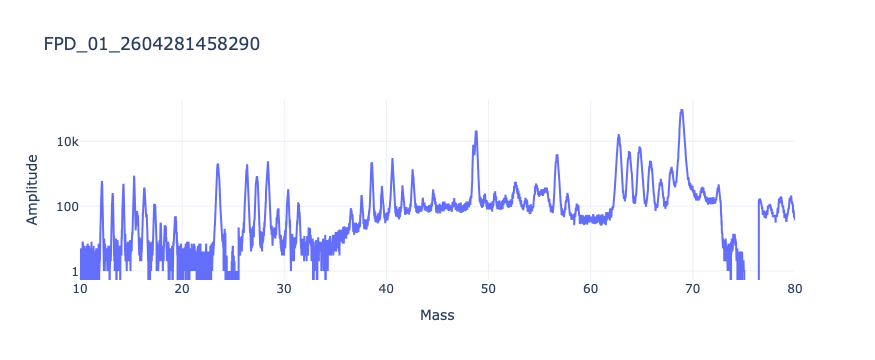

In [7]:
fig = spec.plot_interactive(log_y=True, xlim=(10, 80))
fig

## Interactive peak labels

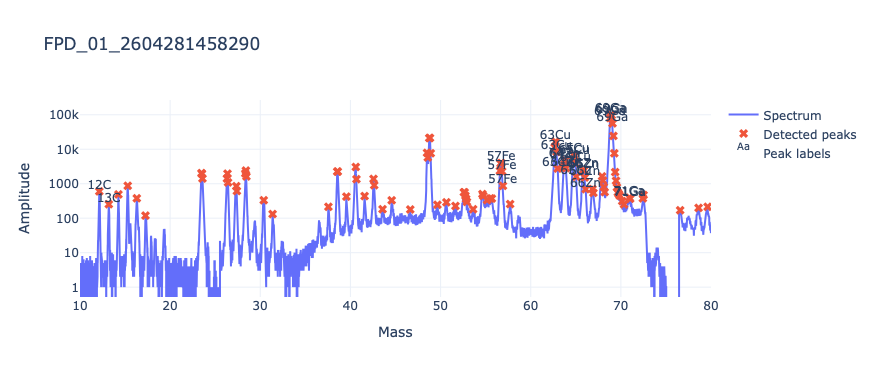

In [3]:
fig, assignments = spec.plot_with_peaks_interactive(
    isotope_table=isotopes,
    tolerance=0.2,
    prominence=100,
    distance=5,
    log_y=True,
    xlim=(10, 80),
)

fig

## Interactive isotope markers

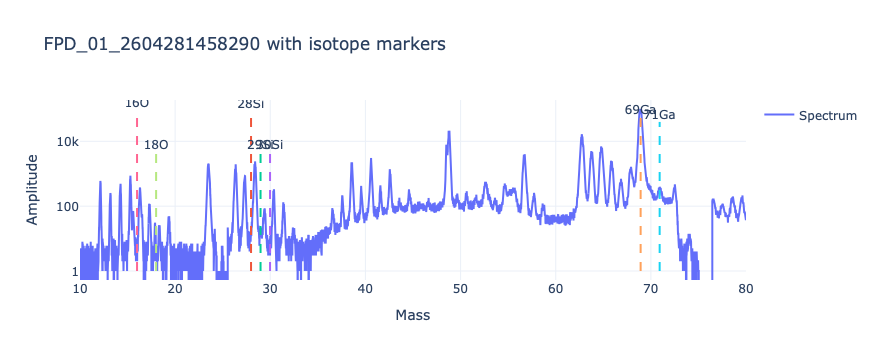

In [4]:
fig = spec.plot_with_element_markers_interactive(
    isotope_table=isotopes,
    elements=["Si", "Ga", "O"],
    log_y=True,
    xlim=(10, 80),
    min_abundance=0.1,
)

fig

## Manual peak binning

In [5]:
bins = manual_peak_binner_interactive(
    spec,
    log_y=True,
    xlim=(20, 40),
)

# After adding bins interactively:
# import pandas as pd
# pd.DataFrame(bins)